# INF8111 - Fouille de données 
## Été 2026 - TP1 - Préparation des données de séries temporelles-Consommation électrique
### Membres de l'équipe 
    - Bantsimbas, Evan Alix - 2450586 - 1
    - Kouassi, Kylian - 2194817 - 2
    - Yandjeu Nana, Ariel De Guilique  - 2495529 - 3


## Instructions de remise 

Vous devez remettre dans la boîte de remise sur moodle ce fichier nommé TP1\_NomDuMembre1\_NomDuMembre2\_NomDuMembre3.ipynb

**N.B**: Assurez-vous que tous les résultats soient lisibles lorsque le notebook est ouvert.

Ce notebook doit être remis avant le **24 mai 2026 à 23h59***. À l'ouverture du Notebook, toutes les réponses doivent être visibles. Tout travail en retard sera pénalisé d’une valeur de 10\% par jour ouvrable de retard.

## Barème

    Partie 1: 20 points
    
    Partie 2: 30 points
    
    Partie 3: 50 points
    
    Pour un total de 100 points.

## Séries temporelles 

Les séries temporelles sont de plus en plus utilisées dans plusieurs domaines tels aue la finance, la météorologie, la santé et la gestion de l'énergie pour modéliser, analyser et prévoir des phénomènes évolutifs. Une série temporelle correspond à une suite d’observations ordonnées dans le temps, collectées à intervalles réguliers ou irréguliers (par exemple : prix journaliers d’une action, température horaire, consommation électrique, etc.). 
Ces données présentent une structure particulière caractérisée par la dépendance entre les observations successives. À partir de ces données temporelles, il devient possible d’identifier des tendances à long terme, des cycles saisonniers, ainsi que des anomalies ou événements inhabituels. Par exemple, en finance, elles servent à anticiper les fluctuations des marchés ; en météorologie, à prévoir les conditions climatiques ; en santé, à suivre l’évolution de paramètres physiologiques ; et dans l’énergie, à optimiser la production ou la consommation.

    
### But
Le but de ce TP est de vous donner un aperçu de la fouille de données dans le cas des séries temporelles. En raison des crises énergétiques, des études de fouille et d'analyse de données peuvent être faites afin de prendre des décisions qui favorisent une consommation optimale de l'énergie électrique. Le but de ce TP est d'extraire des informations pertinentes à partir des données de consommation d'énergie électrique qui sont fournies. 

### Importation des différents modules 

In [1]:
# Installation des librairies 

# !pip install pandas
# !pip install numpy
# !pip install scikit-learn
# !pip install seaborn
# !pip install matplotlib
# !pip install plotly
# !pip install statsmodels

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Informations sur les données 
Nous vous avons fourni le fichier data.csv avec l'exécution de cellule suivante. Il contient l'ensemble des données. Il s'agit des mesures collectées dans une maison située à Sceaux (à 7 km de Paris, France) entre décembre 2006 et novembre 2010. Chaque ligne contient les données d'une vente. La description des attributs du dataset est la suivante:

| # | Feature Name           | Description |
|---|------------------------|-------------|
| 1 | Date                  | Date / Date au format jj/mm/aaaa |
| 2 | Time                  | Heure / Heure au format hh:mm:ss |
| 3 | Global_active_power   | Puissance active globale / Household global minute-averaged active power (in kilowatt) |
| 4 | Global_reactive_power | Puissance réactive globale / Household global minute-averaged reactive power (in kilowatt) |
| 5 | Voltage               | Tension / Minute-averaged voltage (in volt) |
| 6 | Global_intensity      | Intensité globale / Household global minute-averaged current intensity (in ampere) |
| 7 | Sub_metering_1        | Sous-comptage 1 / Energy sub-metering No. 1 (cuisine : lave-vaisselle, four, micro-ondes) |
| 8 | Sub_metering_2        | Sous-comptage 2 / Energy sub-metering No. 2 (buanderie : machine à laver, sèche-linge, réfrigérateur, lumière) |
| 9 | Sub_metering_3        | Sous-comptage 3 / Energy sub-metering No. 3 (chauffage électrique et climatisation) |

Notons que (global_active_power×1000/60−sub_metering_1−sub_metering_2−sub_metering_3) représente l’énergie active consommée chaque minute (en watt-heure) dans le foyer par les équipements électriques non mesurés par les sous-compteurs 1, 2 et 3.

In [3]:
df = pd.read_csv("data.txt", sep=";", na_values=["?"],low_memory=False)
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


# 1. Nettoyage et préparation de données (5 points)

#### Question 1.1 ( 2 points)
**Combien d'observations contient le dataset ? 

In [4]:
# TO DO
print("Nombre d'observations :", len(df))

Nombre d'observations : 2075259


#### Question 1.2 (3 points)

Supprimer les lignes ayant des valeurs manquantes puis indiquer le nombre de lignes supprimées.  

In [5]:
# TO DO
nb_avant = len(df)

df = df.dropna()

nb_apres = len(df)

print("Lignes supprimées :", nb_avant - nb_apres)

Lignes supprimées : 25979


####  Question 1.3 (4 points)
En visualisant les colonnes du dataset, et en se référant à la description fournie, quels sont les attributs numériques?

In [6]:
# TO DO ( aucun code n'est requis pour répondre à  cette question

# Date	Time, Global_active_power, Global_reactive_power, Voltage, Global_intensity, 
# Sub_metering_1, Sub_metering_2, Sub_metering_3

# La date et le temps sont non numériques

#### Question 1.4 (5 points) 

On veut combiner les colonnes **Date** et **Time** pour créer une seule variable temporelle **dt**, représentant l’instant exact de chaque observation. La colonne **dt** doit être au format **aaaa-mm-jj hh:mm:ss**. Transformez les colonnes **Date** et **Time** en **dt**.

In [7]:
# TO DO
if 'Date' in df.columns:
    df['dt'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], 
                               format='%d/%m/%Y %H:%M:%S')
    df = df.drop(columns=['Date', 'Time'])
    df = df.set_index('dt')

print(df.head())

                     Global_active_power  Global_reactive_power  Voltage  \
dt                                                                         
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
dt                                                                      
2006-12-16 17:24:00              18.4             0.0             1.0   
2006-12-16 17:25:00              23.0             0.0             1.0   
2006-12-16 17:26:00              23.0             0.0             2.0   
2006-12-16 17:27:00              23.0             0.0             1.0   
2006-12-16 17:28:00          

#### Question 1.5 (7,5 points)
a - Afficher la matrice de corrélation entre les différents attributs numériques de nos données. Quelle sont les paires d'attributs fortement correlés ? Utiliser un seuil de 0,75. 

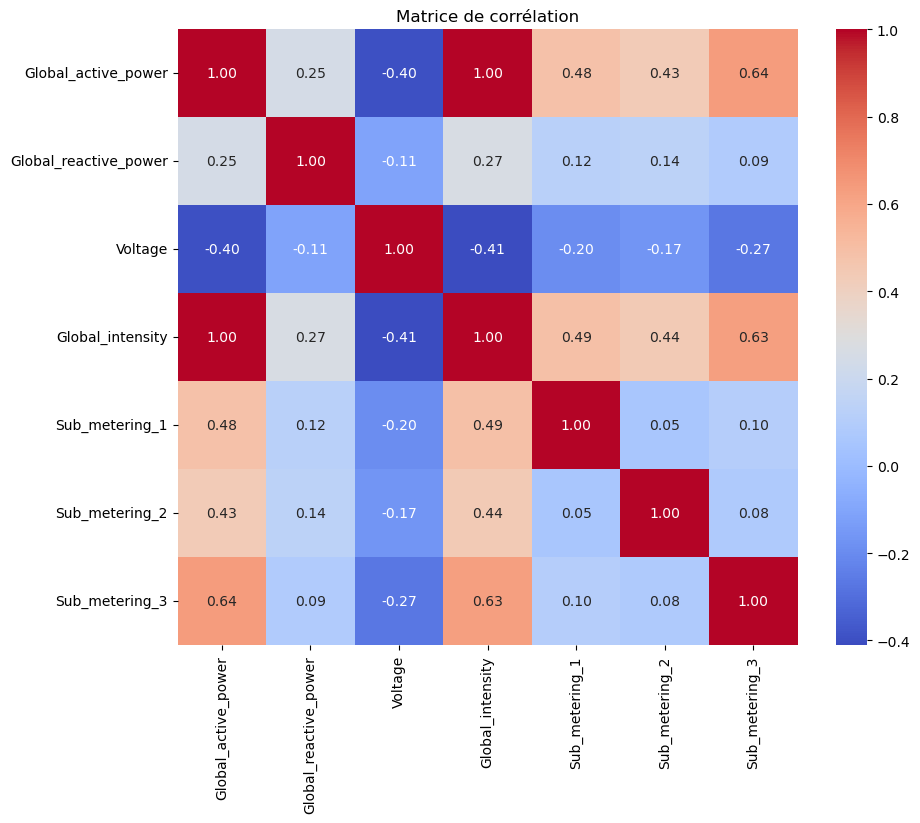

Global_active_power ↔ Global_intensity : 1.00


In [8]:
# TO DO
cols = ['Global_active_power', 'Global_reactive_power', 'Voltage',
        'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

corr = df[cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

# Trouver les paires fortement corrélées (seuil 0.75)
seuil = 0.75
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        val = corr.iloc[i, j]
        if abs(val) >= seuil:
            print(f"{cols[i]} ↔ {cols[j]} : {val:.2f}")

b- Afficher sur un graphe la relation entre les deux attributs ayant la plus forte corrélation. 

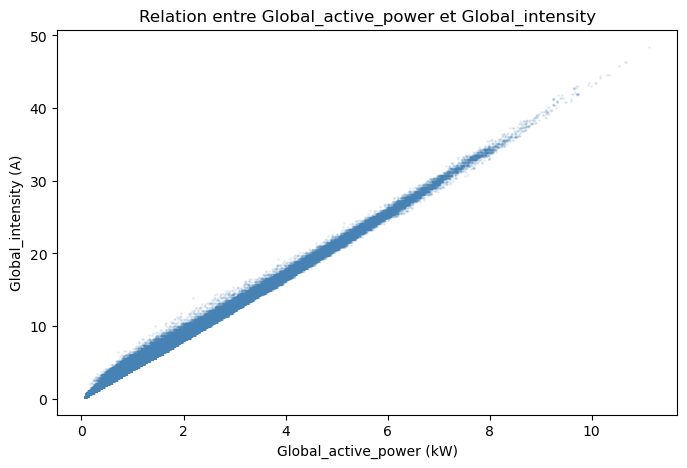

In [9]:
# TO DO
plt.figure(figsize=(8, 5))
plt.scatter(df['Global_active_power'], df['Global_intensity'], 
            alpha=0.1, s=1, color='steelblue')
plt.xlabel('Global_active_power (kW)')
plt.ylabel('Global_intensity (A)')
plt.title('Relation entre Global_active_power et Global_intensity')
plt.show()

# 2. Prédiction standard
De façon classique, un modèle de prédiction indique une relation entre des variables d'entrée et une variable à prédire. Dans cette partie, nous allons prédire  **Global_active_power** en utilisant les autres colonnes.

#### Question 2.1   (5 points)
Pour l'ensemble des données, créer un ensemble de données nommé **data** en remplaçant la colonne **dt** par de nouvelles colonnes **annee**, **mois**, **jour**, **heure** et **minutes**. 
Indiquer pourquoi la colonne **secondes** peut être ignorée pour notre ensemble de données. 

In [10]:
# TO DO
data = df.copy()

data['annee']   = data.index.year
data['mois']    = data.index.month
data['jour']    = data.index.day
data['heure']   = data.index.hour
data['minutes'] = data.index.minute

print(data.head())


                     Global_active_power  Global_reactive_power  Voltage  \
dt                                                                         
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
dt                                                                      
2006-12-16 17:24:00              18.4             0.0             1.0   
2006-12-16 17:25:00              23.0             0.0             1.0   
2006-12-16 17:26:00              23.0             0.0             2.0   
2006-12-16 17:27:00              23.0             0.0             1.0   
2006-12-16 17:28:00          

#### Question 2.2 (5 points)
On peut normaliser les données. 

*   La `standardisation` normalise les données en soustrayant la moyenne et en divisant par l'écart-type
*   `Min-Max Scaling` normalise les données en les ramenant entre 0 et 1.

Réaliser la normalisation des données par `standardisation`. On peut utiliser la fonction `StandardScaler()` de `sklearn`.

In [11]:
# TO DO
from sklearn.preprocessing import StandardScaler

features = ['Global_reactive_power', 'Voltage', 'Global_intensity',
            'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3',
            'annee', 'mois', 'jour', 'heure', 'minutes']

scaler = StandardScaler()
data[features] = scaler.fit_transform(data[features])

print(data.head())

                     Global_active_power  Global_reactive_power   Voltage  \
dt                                                                          
2006-12-16 17:24:00                4.216               2.610721 -1.851816   
2006-12-16 17:25:00                5.360               2.770406 -2.225274   
2006-12-16 17:26:00                5.374               3.320432 -2.330213   
2006-12-16 17:27:00                5.388               3.355917 -2.191324   
2006-12-16 17:28:00                3.666               3.586573 -1.592556   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
dt                                                                      
2006-12-16 17:24:00          3.098789       -0.182337       -0.051274   
2006-12-16 17:25:00          4.133800       -0.182337       -0.051274   
2006-12-16 17:26:00          4.133800       -0.182337        0.120487   
2006-12-16 17:27:00          4.133800       -0.182337       -0.051274   
2006-12-16 17:28:00   

#### Question 2.3 (5 points)
On va séparer les données en un ensemble d'entraînement et un ensemble de test qu'on va nommer respectivement 'data_train' et 'data_test'. Utiliser les données jusqu'à fin 2009 pour l'apprentissage, et celles de 2010 pour le test.

Effectuer la séparartion des données.

In [12]:
# TO DO
data_train = data[data.index.year <= 2009]
data_test  = data[data.index.year == 2010]

print("Taille entraînement :", len(data_train))
print("Taille test :", len(data_test))

Taille entraînement : 1591886
Taille test : 457394


### Question 2.4 - Entrainement de modèle de régression linéaire

La régression linéaire consiste à trouver une fonction affine qui minimise la somme des carrés des erreurs. La fonction affine est définie par la formule suivante :
$$ f(x) = \beta_0 + \beta_1^T x $$
Il consiste à trouver les paramètres $\beta_0$ et $\beta_1$ qui minimisent $\sum_{i=1}^n (f(x_i) - y_i)^2=||y-X\beta||^2$ où $X$ est la matrice des données fournies au modèle et $y$ le vecteur des `Global_active_power`.

La métrique RMSE (Root Mean Square Error) est une métrique utilisée pour mesurer la différence moyenne entre les valeurs prédites par un modèle et les valeurs observées.

#### Question 2.4.1 (10 points )
Entrainer un modèle de regresion linéaire avec **data_train** et  calculer la RMSE correspondante aux données de l'ensemble de test.

In [13]:
# TO DO
from sklearn.metrics import mean_squared_error

# Séparer les variables d'entrée (X) et la cible (y)
target = 'Global_active_power'

X_train = data_train.drop(columns=[target])
y_train = data_train[target]

X_test = data_test.drop(columns=[target])
y_test = data_test[target]

# Créer et entraîner le modèle
model = linear_model.LinearRegression()
model.fit(X_train, y_train)

# calculer la RMSE
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE :", rmse)

RMSE : 0.039395524918261565


La prédiction est obtenue. On peut maintenant mesurer l'importance de chaque attribut dans la prédicition en se référant aux coefficients de la régression linéaire.
#### Question 2.4.2  (5 points)
Quels sont les trois attributs ayant le plus d'impact dans la prédiction ?

Les 3 attributs les plus importants :
Global_intensity         1.056285
Global_reactive_power    0.019740
Sub_metering_3           0.018621
dtype: float64


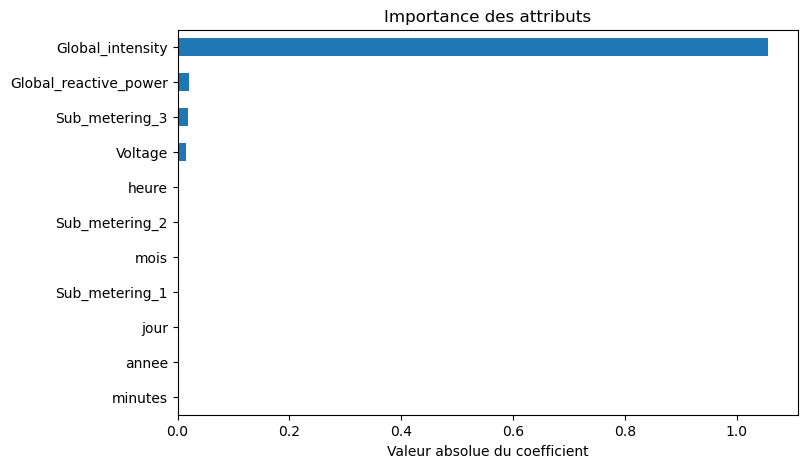

In [14]:
# TO DO
coefs = pd.Series(model.coef_, index=X_train.columns)

top3 = coefs.abs().sort_values(ascending=False).head(3)
print("Les 3 attributs les plus importants :")
print(top3)

# Visualisation de tous les coefficients
coefs.abs().sort_values().plot(kind='barh', figsize=(8, 5))
plt.title("Importance des attributs")
plt.xlabel("Valeur absolue du coefficient")
plt.show()

In [15]:
# On copie les données pour les utiliser dans la partie 3. 
dft = df.copy()

# 3. Prédiction de série temporelle 
Dans la partie précédente, la prédiction d'une valeur nécessite la connaissance des valeurs des autres attributs de l'observation concernée. On n'a pas toujours ces valeurs et pourtant on peut faire de prédiction dans ces situations. Les séries temporelles sont plus adaptées dans ces situations. La prédiction de séries temporelles consiste à estimer les valeurs futures d’une variable en se basant sur ses observations passées. 

Dans la suite du TP, seuls les attributs **Global_active_power** et **dt** vont être utilisés. La cellule suivante permet de réduire les données.

In [16]:
# Exécuter ce code pour afficher les données obtenues.
# Si la colonne 'dt' n'apparait pas en 'indice', vous pouvez l'ajouter ici.
dft = dft['Global_active_power']
dft

dt
2006-12-16 17:24:00    4.216
2006-12-16 17:25:00    5.360
2006-12-16 17:26:00    5.374
2006-12-16 17:27:00    5.388
2006-12-16 17:28:00    3.666
                       ...  
2010-11-26 20:58:00    0.946
2010-11-26 20:59:00    0.944
2010-11-26 21:00:00    0.938
2010-11-26 21:01:00    0.934
2010-11-26 21:02:00    0.932
Name: Global_active_power, Length: 2049280, dtype: float64

## 3.1 Analyse préliminaire des données

#### Question 3.1.1 ( 3 points)
Calculer et afficher sur un graphe la consommation moyenne de **Global_active_power** pour chaque mois de l'année.

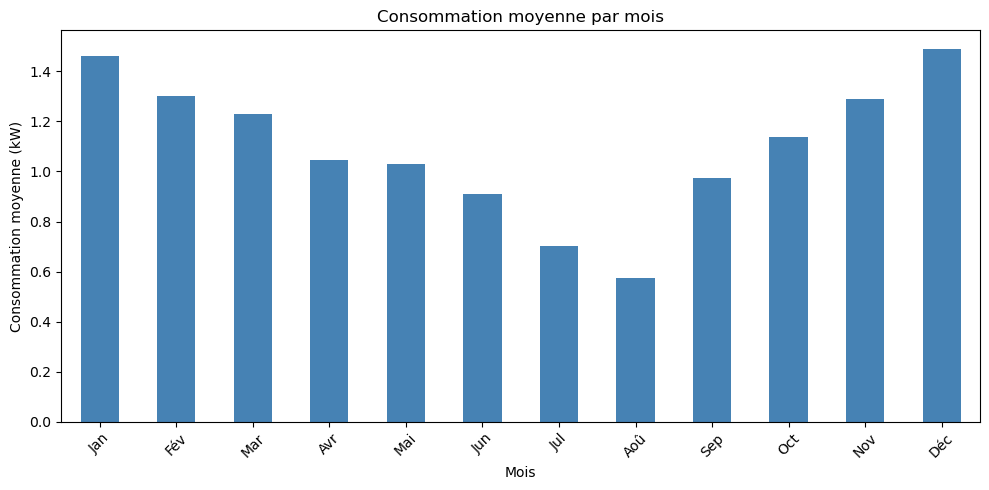

In [18]:
# TO DO
conso_par_mois = dft.groupby(dft.index.month).mean()

plt.figure(figsize=(10, 5))
conso_par_mois.plot(kind='bar', color='steelblue')
plt.xlabel('Mois')
plt.ylabel('Consommation moyenne (kW)')
plt.title('Consommation moyenne par mois')
plt.xticks(range(12), ['Jan','Fév','Mar','Avr','Mai','Jun',
                        'Jul','Aoû','Sep','Oct','Nov','Déc'], rotation=45)
plt.tight_layout()
plt.show()

Les données fournies sont en minutes. Pour la suite du TP, on va réduire la taille des données en faisant un rééchantillonnage des données en utilisant la somme par jour. La cellule suivante permet de faire cette réduction et de visualiser les données obtenues.

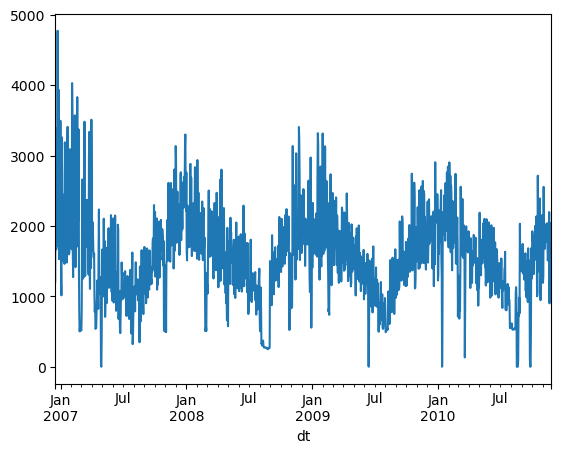

In [19]:
# Exécuter ce code pour afficher les données réduites
df_journalier = dft.resample('d').sum()
df_journalier.plot()
plt.show()

#### Question 3.1.2 (3 points)
En utilisant la fonction **seasonal_decompose** de la librairie **statsmodels**, effectuer une décomposition de la série temporelle journalière (df_journalier) avec une période de 6 mois.

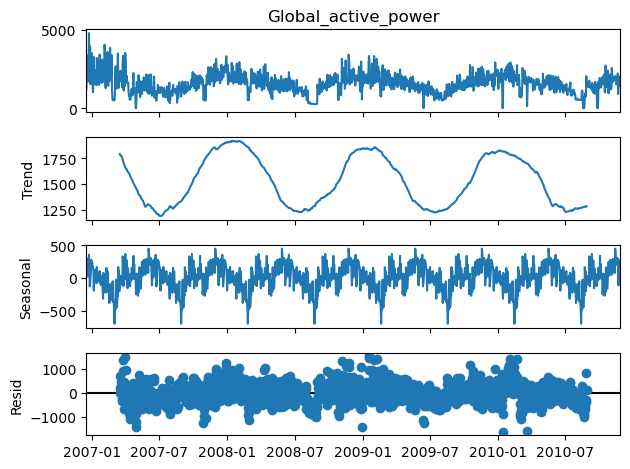

In [20]:
# TO DO
result = seasonal_decompose(df_journalier, model='additive', period=180)
result.plot()
plt.tight_layout()
plt.show()

#### Question 3.1.3 (4 points)
Interpréter les résultats obtenus aux questions 3.1.1 et 3.1.2. 
    Quelle périodicité observe-t-on ? 
    Quels mois présentent une consommation plus élevée ?
    Cette information est-elle cohérente avec un usage domestique ?

In [ ]:
# TO DO  
# On observe une périodicité annuelle : la consommation est plus élevée 
# en hiver (janvier, février, décembre) peut être du à l'hiver et la consommation forte avec le chauffage
#et plus faible en été (juillet, août) les gens en tendance à utiliser moins d'appareil.

# Les mois de janvier et décembre présentent la consommation la plus élevée.

# Cela est cohérent avec un usage domestique : le chauffage électrique 
# est fortement utilisé en hiver, ce qui explique la hausse de consommation.

#### Question 3.1.4 (3 points)
Les **lag features** sont très utilisées dans la prédiction des séries temporelles. Elles permettent de saisir les tendances temporelles des données en générant de nouvelles variables à partir des valeurs passées. Ces variables permettent d'utiliser les valeurs passées pour prédire les valeurs futures. Par exemple, la prédiction de la consommation d'aujourd'hui pourrait dépendre de la consommation du même jour de l'année passée. Dans ce cas, la consommation d'il y a un an constituerait une lag feature.
Vous pouvez consulter le [lien](https://www.kaggle.com/code/ryanholbrook/time-series-as-features/tutorial) suivant pour un apperçu du lag embedding. 


Quelle valeur est adéqate pour une variable lagged dans ce cas ? Justifier votre réponse.

In [ ]:
# TO DO (aucun code n'est requis pour répondre à cette question
# Étant donné que janvier 2007 ressemble à janvier 2008, qui ressemble à janvier 2009 on observe un cycle annuel
# La valeur adéquate pour une variable lagged dans ce cas est 365 jours.


### 3.2  Modèle de régression linéaire 
Nous allons appliquer la régression linéaire sur nos données réduites. Pour cela, on doit transformer le problème de séries temporelles en un problème d'apprentissage supervisé. On va créer des "lagged features" pour accomplir cette tâche, puis diviser les données obtenues en des ensembles d'apprentissage et de test, respectivement les données jusqu'à fin 2009 pour l'apprentissage, et celles de 2010 pour le test. 

#### Question 3.2 (12.5 points)
Entraîner un modèle de regresion linéaire dans ce cas. Pour cela, créer une variable 'lags' permettant de garder en mémoire à chaque jour la consommation d'un jour du passé. Calculer la RMSE correspondante aux données prédites. 

In [21]:
# TO DO
# Créer le DataFrame avec le lag de 365 jours
df_lag = df_journalier.to_frame()
df_lag['lag_365'] = df_lag['Global_active_power'].shift(365)
df_lag = df_lag.dropna()

# Séparation train/test
train = df_lag[df_lag.index.year <= 2009]
test  = df_lag[df_lag.index.year == 2010]

X_train = train[['lag_365']]
y_train = train['Global_active_power']
X_test  = test[['lag_365']]
y_test  = test['Global_active_power']

# Entraîner le modèle
model_ts = linear_model.LinearRegression()
model_ts.fit(X_train, y_train)

# Prédire et calculer la RMSE
y_pred_ts = model_ts.predict(X_test)
rmse_ts = np.sqrt(mean_squared_error(y_test, y_pred_ts))
print("RMSE (régression linéaire avec lag) :", rmse_ts)

RMSE (régression linéaire avec lag) : 500.8605793047217


### 3.3 Entrainement d'un modèle au choix
#### Question 3.3 (12.5 points)
Pour les mêmes périodes de sous-ensembles de données, entrainer un modèle de votre choix et calculer la RMSE correspondante. Justifiez votre choix.

Toute tranformation des données réduites avant l'entrainement est autorisée ici. L'obtention d'un RMSE meilleur au précédent sera valorisée. 

In [22]:
# TO DO
from sklearn.ensemble import RandomForestRegressor

# Créer plusieurs lags pour enrichir le modèle
df_multi = df_journalier.to_frame()
df_multi['lag_1']   = df_multi['Global_active_power'].shift(1)
df_multi['lag_7']   = df_multi['Global_active_power'].shift(7)
df_multi['lag_30']  = df_multi['Global_active_power'].shift(30)
df_multi['lag_365'] = df_multi['Global_active_power'].shift(365)
df_multi = df_multi.dropna()

# Séparation train/test
lag_cols = ['lag_1', 'lag_7', 'lag_30', 'lag_365']
train2 = df_multi[df_multi.index.year <= 2009]
test2  = df_multi[df_multi.index.year == 2010]

X_train2 = train2[lag_cols]
y_train2 = train2['Global_active_power']
X_test2  = test2[lag_cols]
y_test2  = test2['Global_active_power']

# Entraîner le Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train2, y_train2)

# Prédire et calculer la RMSE
y_pred_rf = rf.predict(X_test2)
rmse_rf = np.sqrt(mean_squared_error(y_test2, y_pred_rf))
print("RMSE (Random Forest) :", rmse_rf)


RMSE (Random Forest) : 406.7374002986138


### 3.4 Évaluation des deux modèles 

#### Question 3.4.1 (7 points)
Pour chacun des deux modèles précédents, afficher sur une figure les observations réelles de **Global_active_power** et celles prédites en fonction du temps pour l'année 2010.

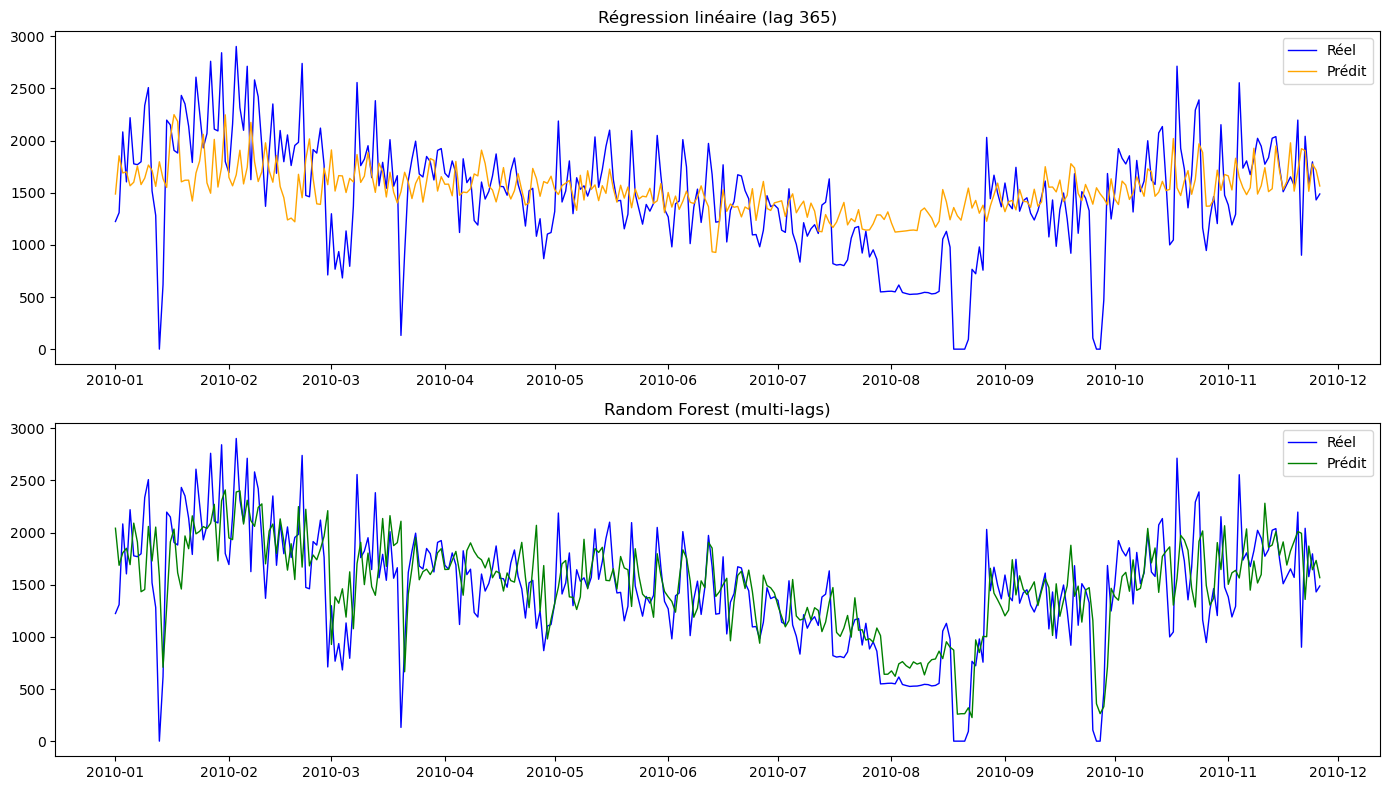

In [23]:
# TO DO
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Modèle 1 : régression linéaire
axes[0].plot(test.index, y_test, label='Réel', color='blue', linewidth=1)
axes[0].plot(test.index, y_pred_ts, label='Prédit', color='orange', linewidth=1)
axes[0].set_title('Régression linéaire (lag 365)')
axes[0].legend()

# Modèle 2 : Random Forest
axes[1].plot(test2.index, y_test2, label='Réel', color='blue', linewidth=1)
axes[1].plot(test2.index, y_pred_rf, label='Prédit', color='green', linewidth=1)
axes[1].set_title('Random Forest (multi-lags)')
axes[1].legend()

plt.tight_layout()
plt.show()

#### Question 3.4.2  (5 points)
En se basant sur les graphes obtenus à la question précédente et sur les RMSE obtenus pour les deux modèles, faites une analyse comparative des résultats. 

In [ ]:
# TO DO ( aucun code n'est requis pour répondre à  cette question)
#Le Random Forest obtient une RMSE de 406.74, inférieure à celle 
#de la régression linéaire (500.86), soit une amélioration d'environ 19%.

#Sur les graphiques, la régression linéaire produit une courbe lisse 
#qui rate les pics et creux importants. Le Random Forest suit  
#mieux les variations réelles grâce à ses 4 lags (1j, 7j, 30j, 365j) 
#qui capturent les tendances à court et long terme.

#Le Random Forest est donc le meilleur modèle pour ce problème.